In [1]:
import os
import sys
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image

import torch
import torch.nn.functional as F
from torchvision import transforms

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
from postprocess import despill_postprocess

from model_spillnet import SpillNet


## config

In [2]:
DEVICE     = 'cuda'
CKPT = '/home/s5820023/Desktop/MC/checkpoints/best.pth'
IMAGE_PATH = '/home/s5820023/Desktop/MC/dataset/image'
FG_PATH    = '/home/s5820023/Desktop/MC/dataset/fg'
ALPHA_PATH = '/home/s5820023/Desktop/MC/dataset/alpha'
TEST_DIR   = '/home/s5820023/Desktop/MC/dataset/test'
INFER_SIZE = 512  


## load model

In [3]:
model = SpillNet(base=64).to(DEVICE)
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
model.eval()

to_tensor = transforms.ToTensor()
print(f"model loaded from {CKPT}")

model loaded from /home/s5820023/Desktop/MC/checkpoints/best.pth


## dataset inference (known alpha)

In [4]:
def predict_frame(folder, filename):
  #run inference on a dataset sample with ground truth alpha 
    image = to_tensor(Image.open(os.path.join(IMAGE_PATH, folder, filename)).convert('RGB'))

    # read fg as RGBA, split rgb and alpha channel  
    fg_rgba = to_tensor(Image.open(os.path.join(FG_PATH, folder, filename)).convert('RGBA'))
    fg_gt   = fg_rgba[:3]   # rgb
    alpha   = fg_rgba[3:]   # a channel  

    image_gpu = image.unsqueeze(0).to(DEVICE)
    alpha_gpu = alpha.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            pred = model(image_gpu, alpha_gpu)
        # post-process despill after network output  
        # strength: 0.5 conservative / 0.8 standard / 1.0 aggressive  
        pred = despill_postprocess(pred.float(), alpha_gpu, strength=0.8)

    def to_np(t):
        # handle both [B,C,H,W] and [C,H,W]  
        return (t.squeeze().cpu().float().permute(1, 2, 0).numpy()
                if t.dim() == 4 else t.squeeze().cpu().float().numpy())

    return (
        image.permute(1, 2, 0).numpy(),
        fg_gt.permute(1, 2, 0).numpy(),
        to_np(pred),
        alpha.squeeze().numpy()
    )


## visualize dataset samples

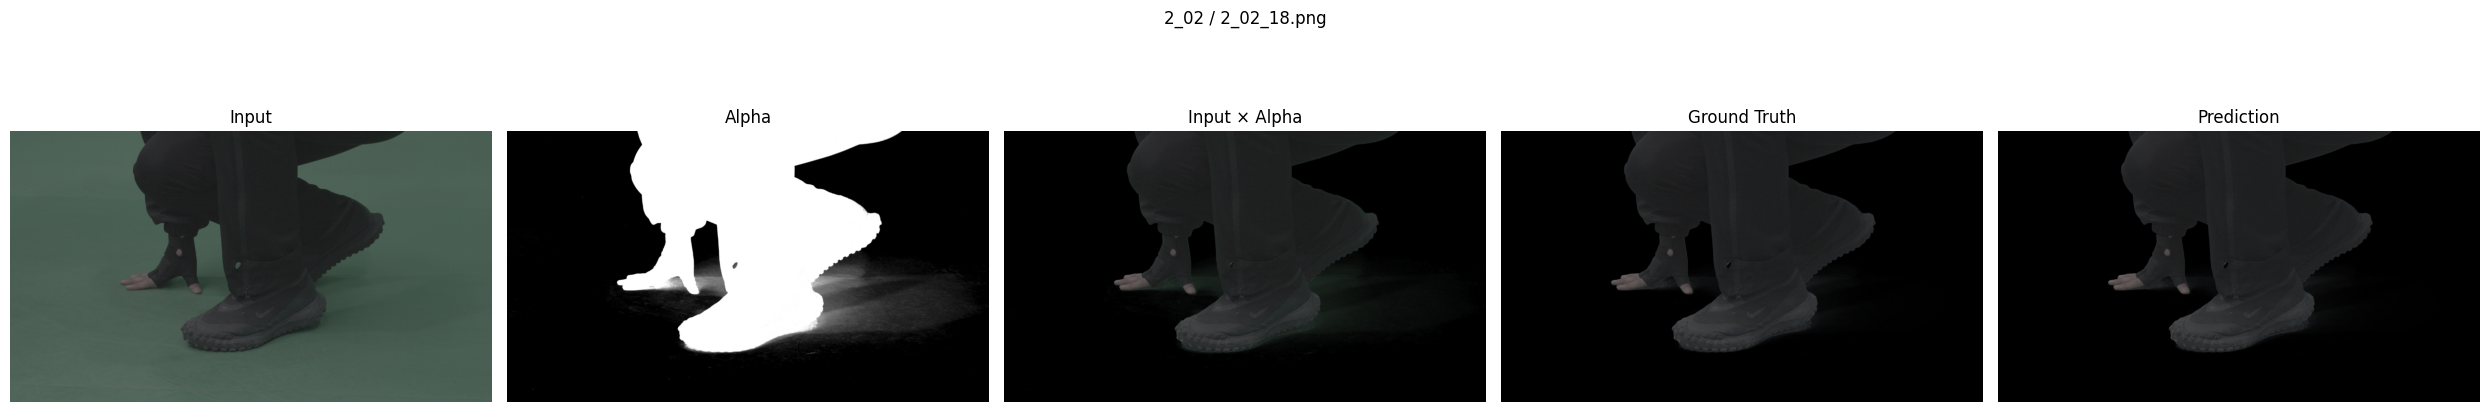

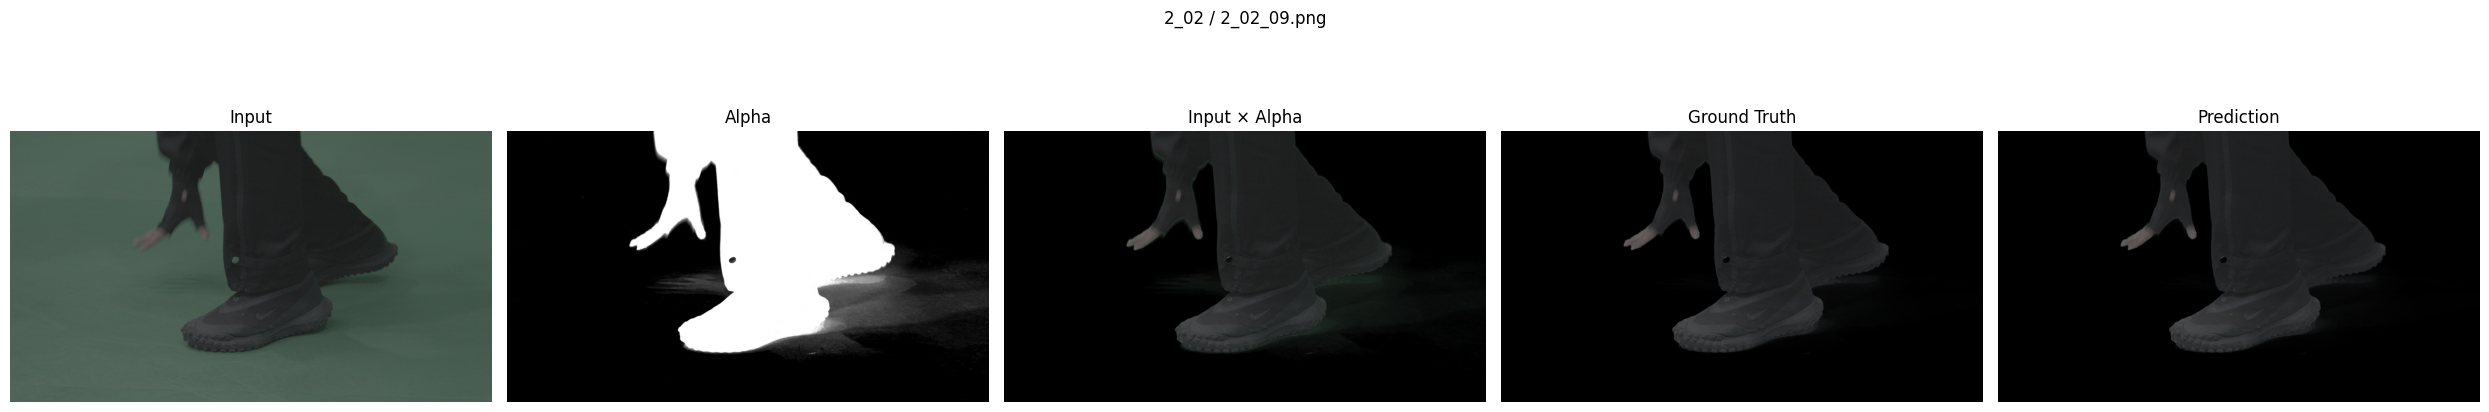

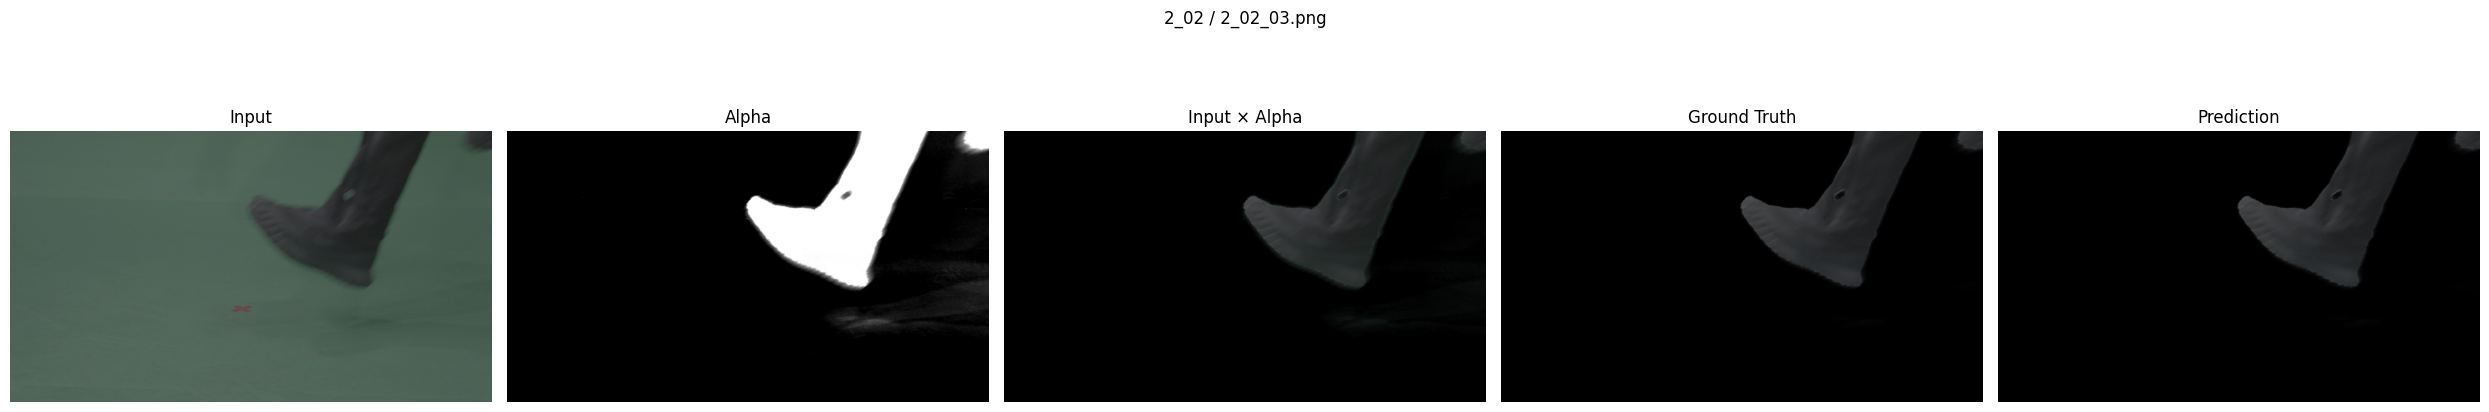

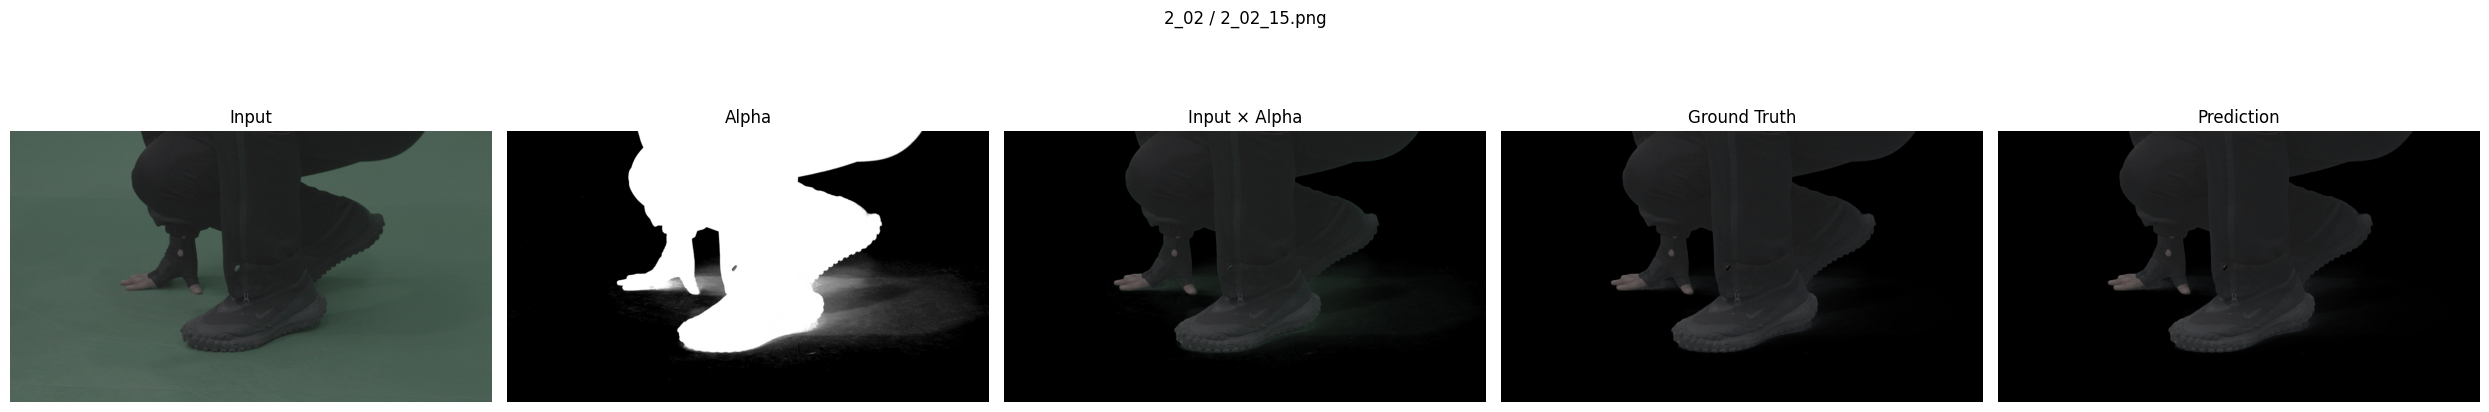

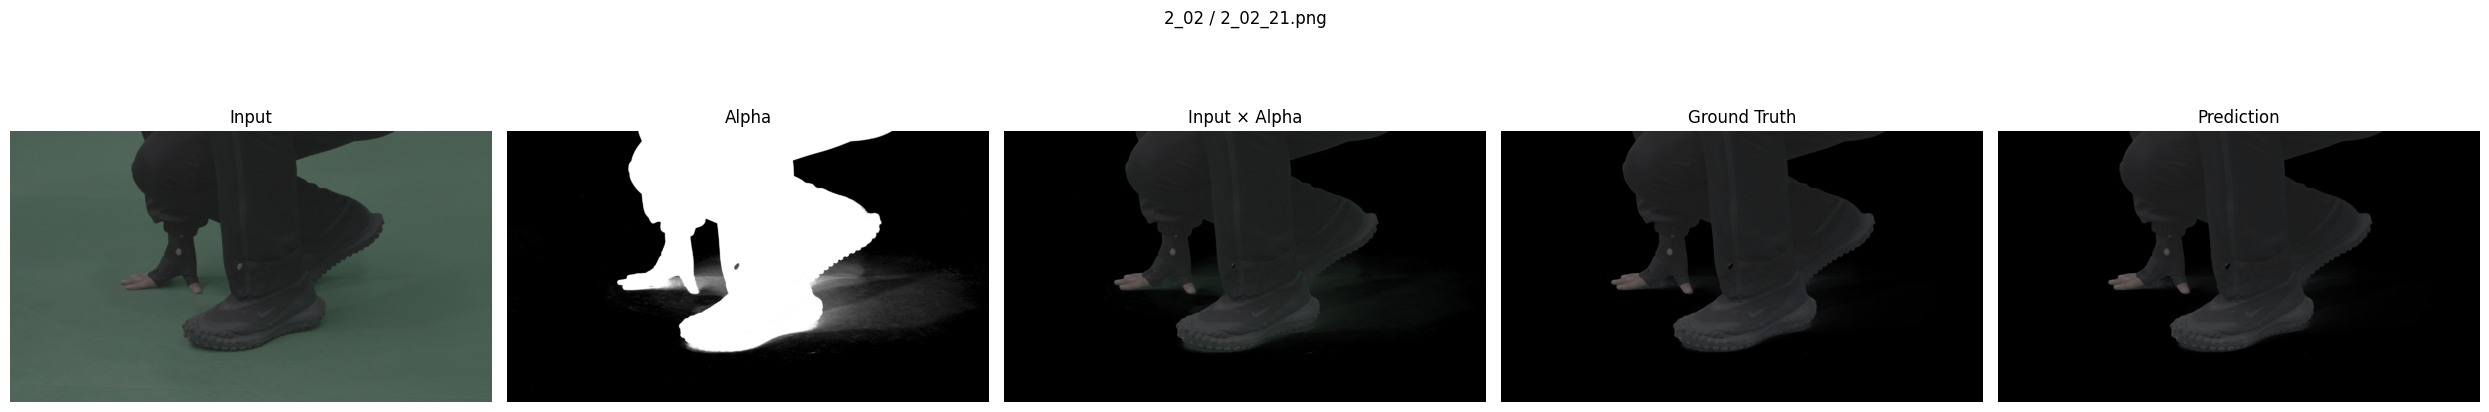

In [5]:
FOLDER     = '2_02'
all_frames = sorted(os.listdir(os.path.join(IMAGE_PATH, FOLDER)))
frames     = random.sample(all_frames, min(5, len(all_frames)))

for fname in frames:
    image_np, fg_gt_np, fg_pred_np, alpha_np = predict_frame(FOLDER, fname)

    alpha_3ch      = alpha_np[:, :, np.newaxis]
    fg_pred_masked = fg_pred_np * alpha_3ch
    fg_gt_masked   = fg_gt_np   * alpha_3ch
    input_masked   = image_np   * alpha_3ch

    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(f'{FOLDER} / {fname}', fontsize=12)

    axes[0].imshow(np.clip(image_np,       0, 1)); axes[0].set_title('Input')
    axes[1].imshow(alpha_np, cmap='gray');          axes[1].set_title('Alpha')
    axes[2].imshow(np.clip(input_masked,   0, 1)); axes[2].set_title('Input × Alpha')
    axes[3].imshow(np.clip(fg_gt_masked,   0, 1)); axes[3].set_title('Ground Truth')
    axes[4].imshow(np.clip(fg_pred_masked, 0, 1)); axes[4].set_title('Prediction')

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## test inference (HSV alpha, no GT)

In [6]:
def predict_frame_test(img_path):
    #run inference on a wild test image, generate alpha via hsv thresholding
   
    image    = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h_orig, w_orig = image.shape[:2]
    image_np = image.astype(np.float32) / 255.0

    # rough green screen alpha via hsv  
    hsv         = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    green_mask  = cv2.inRange(hsv, np.array([35, 40, 40]), np.array([85, 255, 255]))
    alpha_np    = 1.0 - green_mask.astype(np.float32) / 255.0

    # resize to inference size then restore  
    image_small = cv2.resize(image_np, (INFER_SIZE, INFER_SIZE))
    alpha_small = cv2.resize(alpha_np, (INFER_SIZE, INFER_SIZE))

    image_t = torch.from_numpy(image_small).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
    alpha_t = torch.from_numpy(alpha_small).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        pred = model(image_t, alpha_t)

    pred_np = cv2.resize(pred.squeeze(0).permute(1, 2, 0).cpu().numpy(), (w_orig, h_orig))

    return image_np, pred_np, alpha_np, h_orig, w_orig


def get_fg_path(fname):
    """map test filename back to fg folder 
    e.g. 2_01_18.png -> fg/2_01/2_01_18.png"""
    stem   = os.path.splitext(fname)[0]
    folder = '_'.join(stem.split('_')[:2])
    return os.path.join(FG_PATH, folder, fname)


## visualize test samples with GT comparison

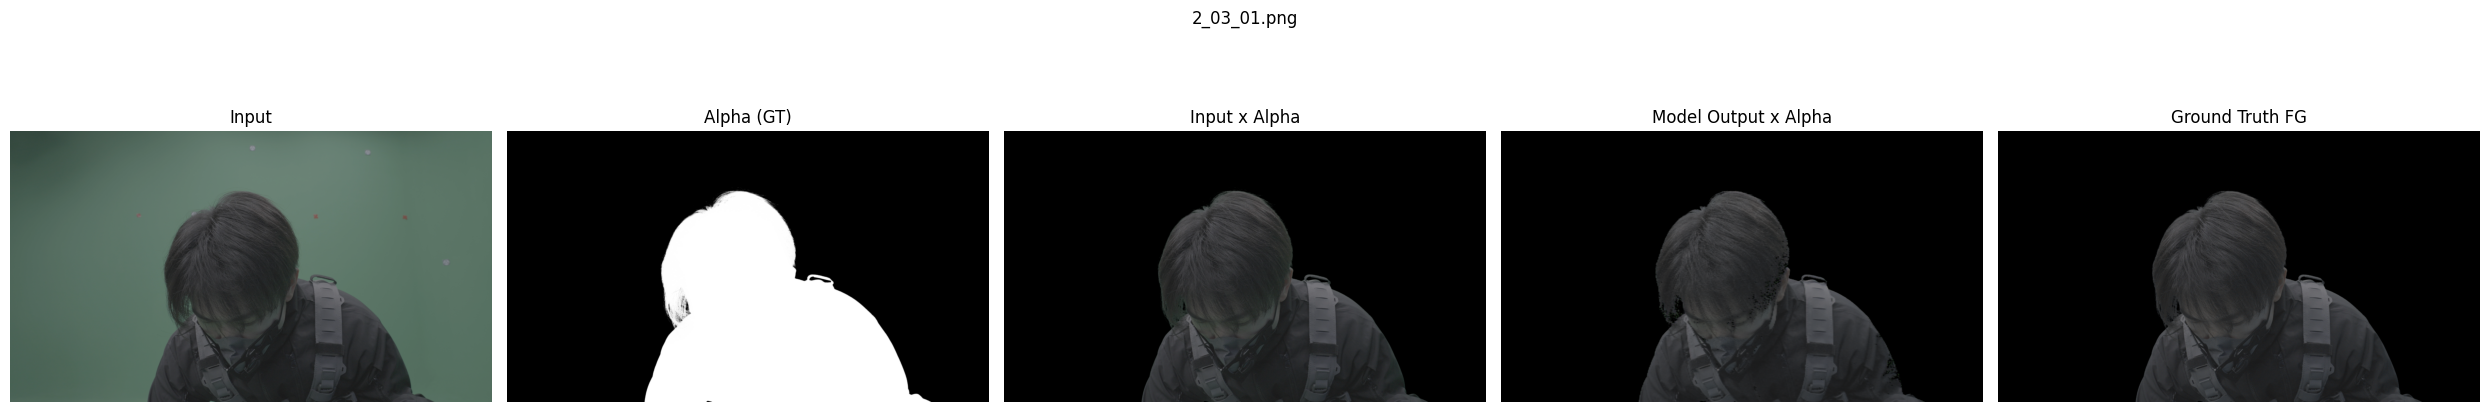

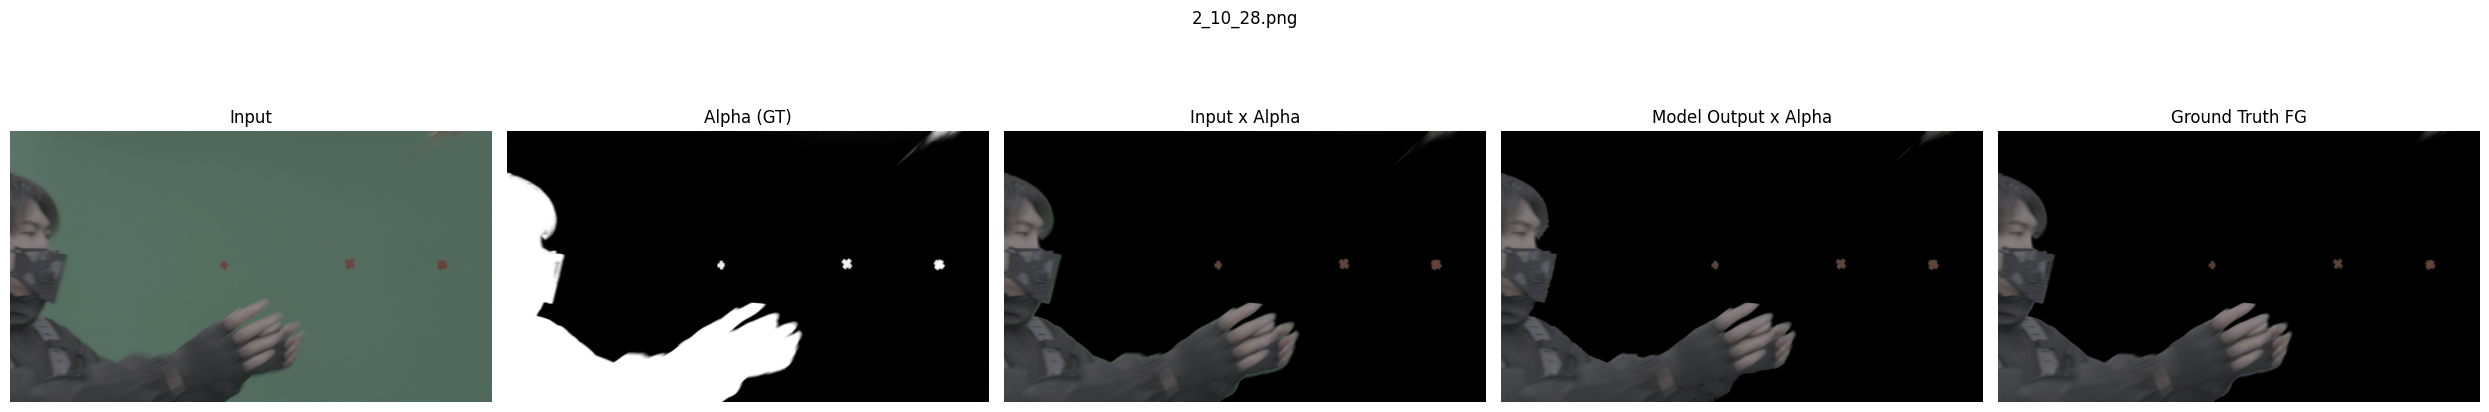

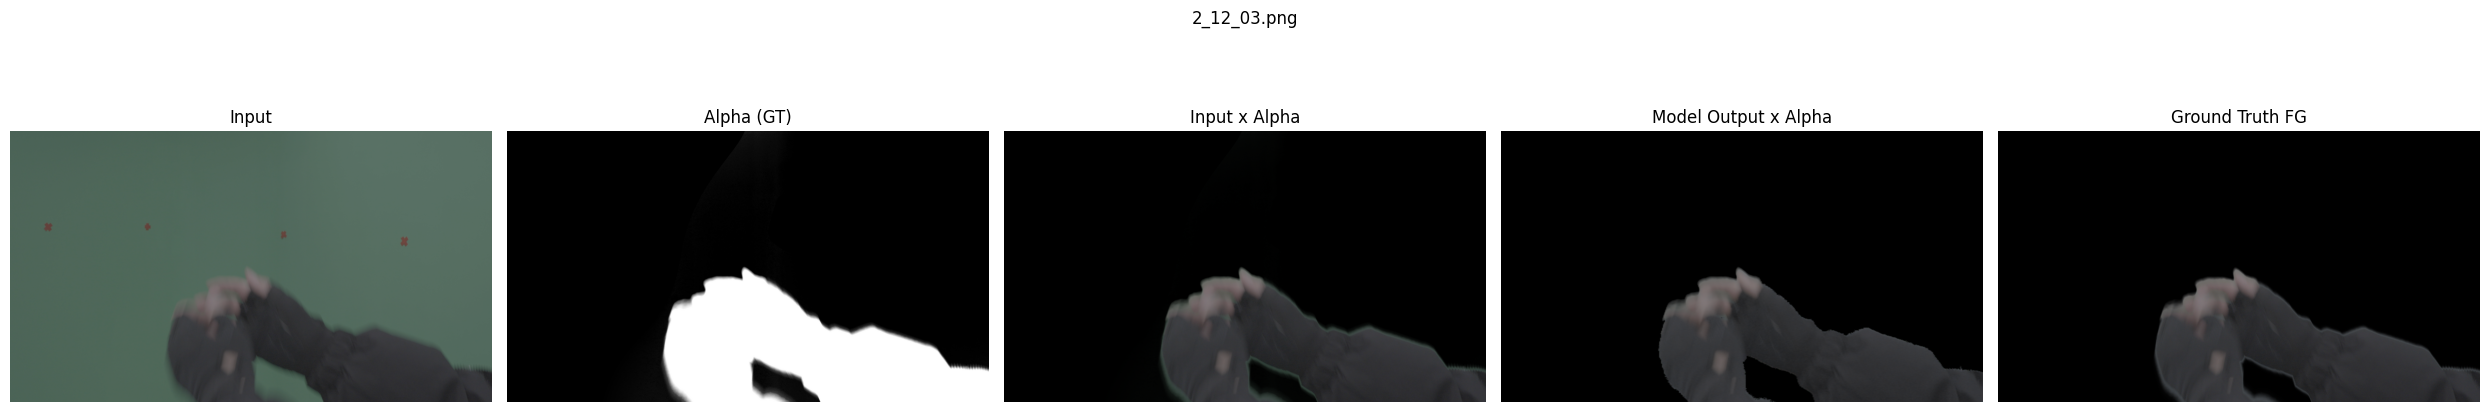

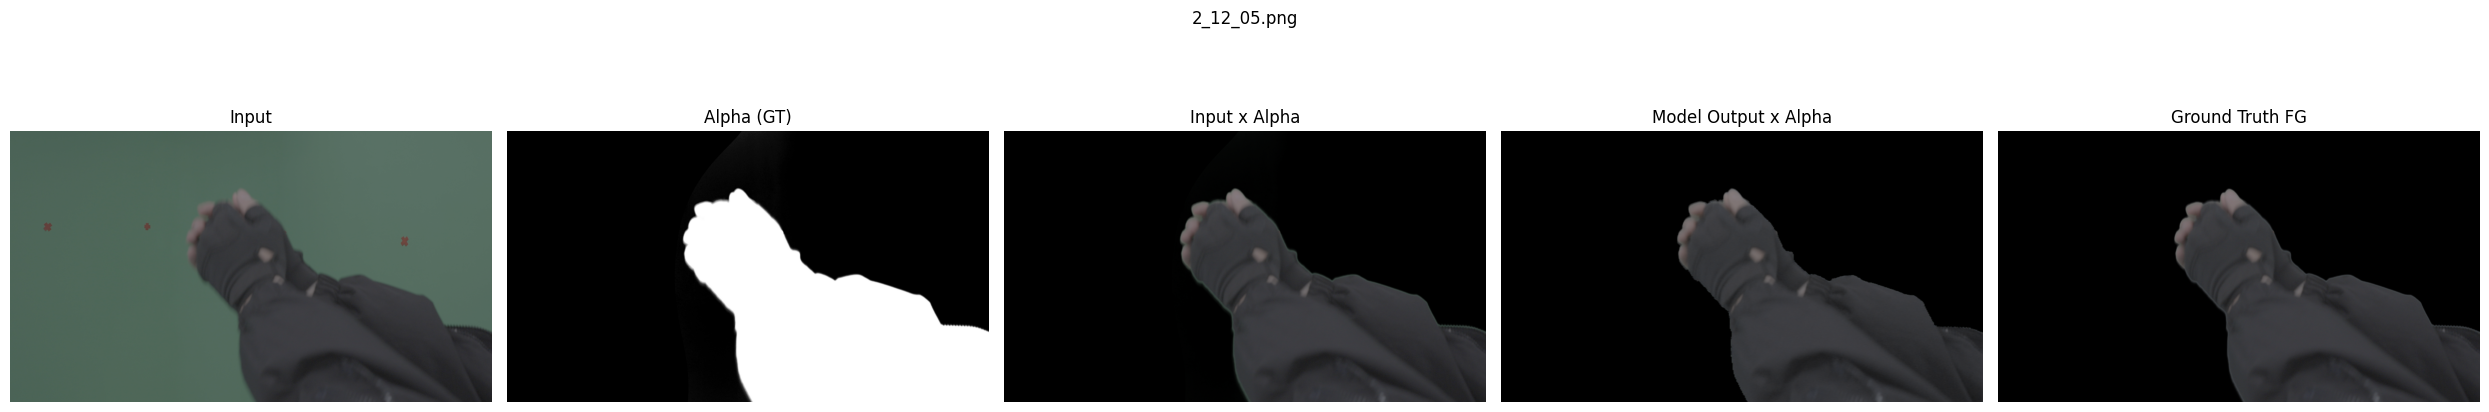

In [7]:
test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])

for fname in test_files:
    fg_path = get_fg_path(fname)
    if not os.path.exists(fg_path):
        continue

    fg_gt = cv2.imread(fg_path, cv2.IMREAD_UNCHANGED).astype(np.float32) / 255.0
    if not (fg_gt.ndim == 3 and fg_gt.shape[2] == 4):
        continue  

    image_np, pred_np, alpha_np, h_orig, w_orig = predict_frame_test(os.path.join(TEST_DIR, fname))
    torch.cuda.empty_cache()

    fg_gt    = cv2.resize(fg_gt, (w_orig, h_orig))
    fg_rgba  = cv2.cvtColor(fg_gt, cv2.COLOR_BGRA2RGBA)
    gt_alpha = fg_rgba[:, :, 3:4] # has alpha channel in png  

    col5 = np.clip(fg_rgba[:, :, :3] * gt_alpha, 0, 1)

    # use gt_alpha consistently across all columns  
    col1 = np.clip(image_np,            0, 1)
    col2 = np.clip(gt_alpha[:, :, 0],   0, 1)
    col3 = np.clip(image_np * gt_alpha, 0, 1)
    col4 = np.clip(pred_np  * gt_alpha, 0, 1)

    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(fname, fontsize=12)

    axes[0].imshow(col1);              axes[0].set_title('Input')
    axes[1].imshow(col2, cmap='gray'); axes[1].set_title('Alpha (GT)')
    axes[2].imshow(col3);              axes[2].set_title('Input x Alpha')
    axes[3].imshow(col4);              axes[3].set_title('Model Output x Alpha')
    axes[4].imshow(col5);              axes[4].set_title('Ground Truth FG')

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


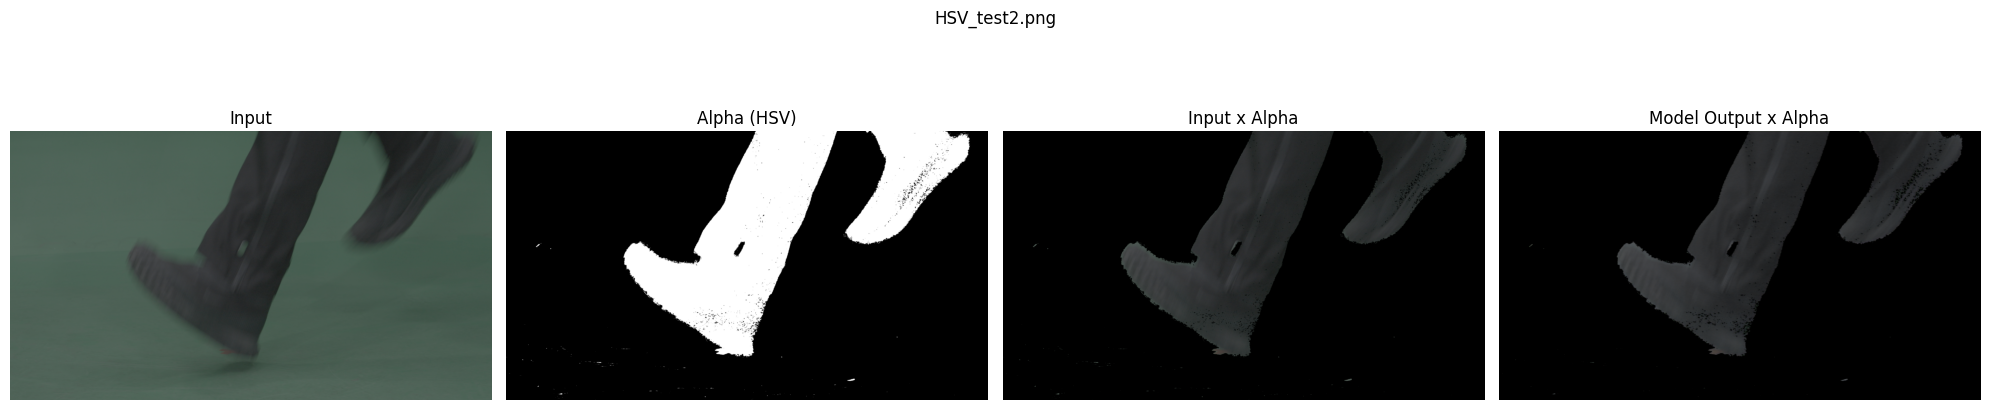

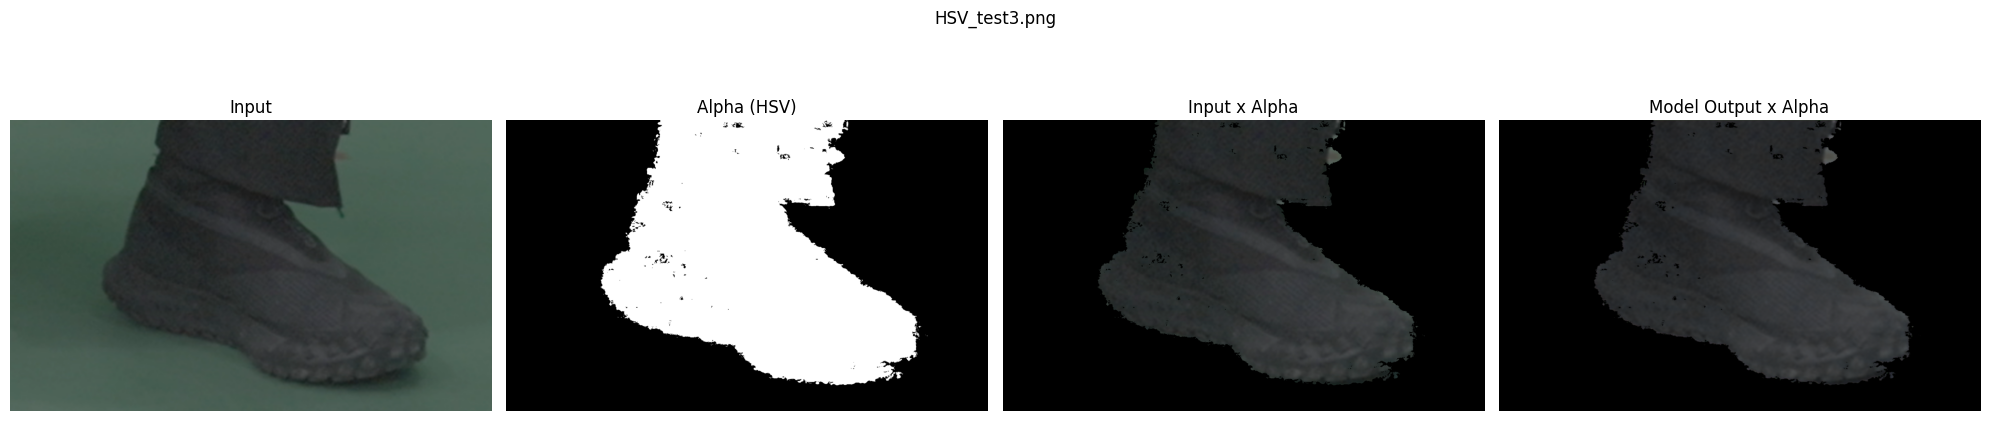

In [8]:
# === Fallback test: images without GT alpha ===
# Since this model only handles despill (not segmentation),
# for images that have no GT alpha, we use a simple HSV-based
# green screen mask as a substitute alpha to preview the
# despill effect. This is NOT a proper evaluation — just a
# quick visual sanity check.

test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])

for fname in test_files:
    fg_path = get_fg_path(fname)
    if os.path.exists(fg_path):
        fg_gt = cv2.imread(fg_path, cv2.IMREAD_UNCHANGED)
        if fg_gt is not None and fg_gt.ndim == 3 and fg_gt.shape[2] == 4:
            continue  # has gt alpha, handled in cell above  

    image_np, pred_np, alpha_np, h_orig, w_orig = predict_frame_test(os.path.join(TEST_DIR, fname))
    torch.cuda.empty_cache()

    gt_alpha = alpha_np[:, :, np.newaxis]   # no alpha channel, fall back to hsv alpha  

    col1 = np.clip(image_np,            0, 1)
    col2 = np.clip(gt_alpha[:, :, 0],   0, 1)
    col3 = np.clip(image_np * gt_alpha, 0, 1)
    col4 = np.clip(pred_np  * gt_alpha, 0, 1)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(fname, fontsize=12)

    axes[0].imshow(col1);              axes[0].set_title('Input')
    axes[1].imshow(col2, cmap='gray'); axes[1].set_title('Alpha (HSV)')
    axes[2].imshow(col3);              axes[2].set_title('Input x Alpha')
    axes[3].imshow(col4);              axes[3].set_title('Model Output x Alpha')

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


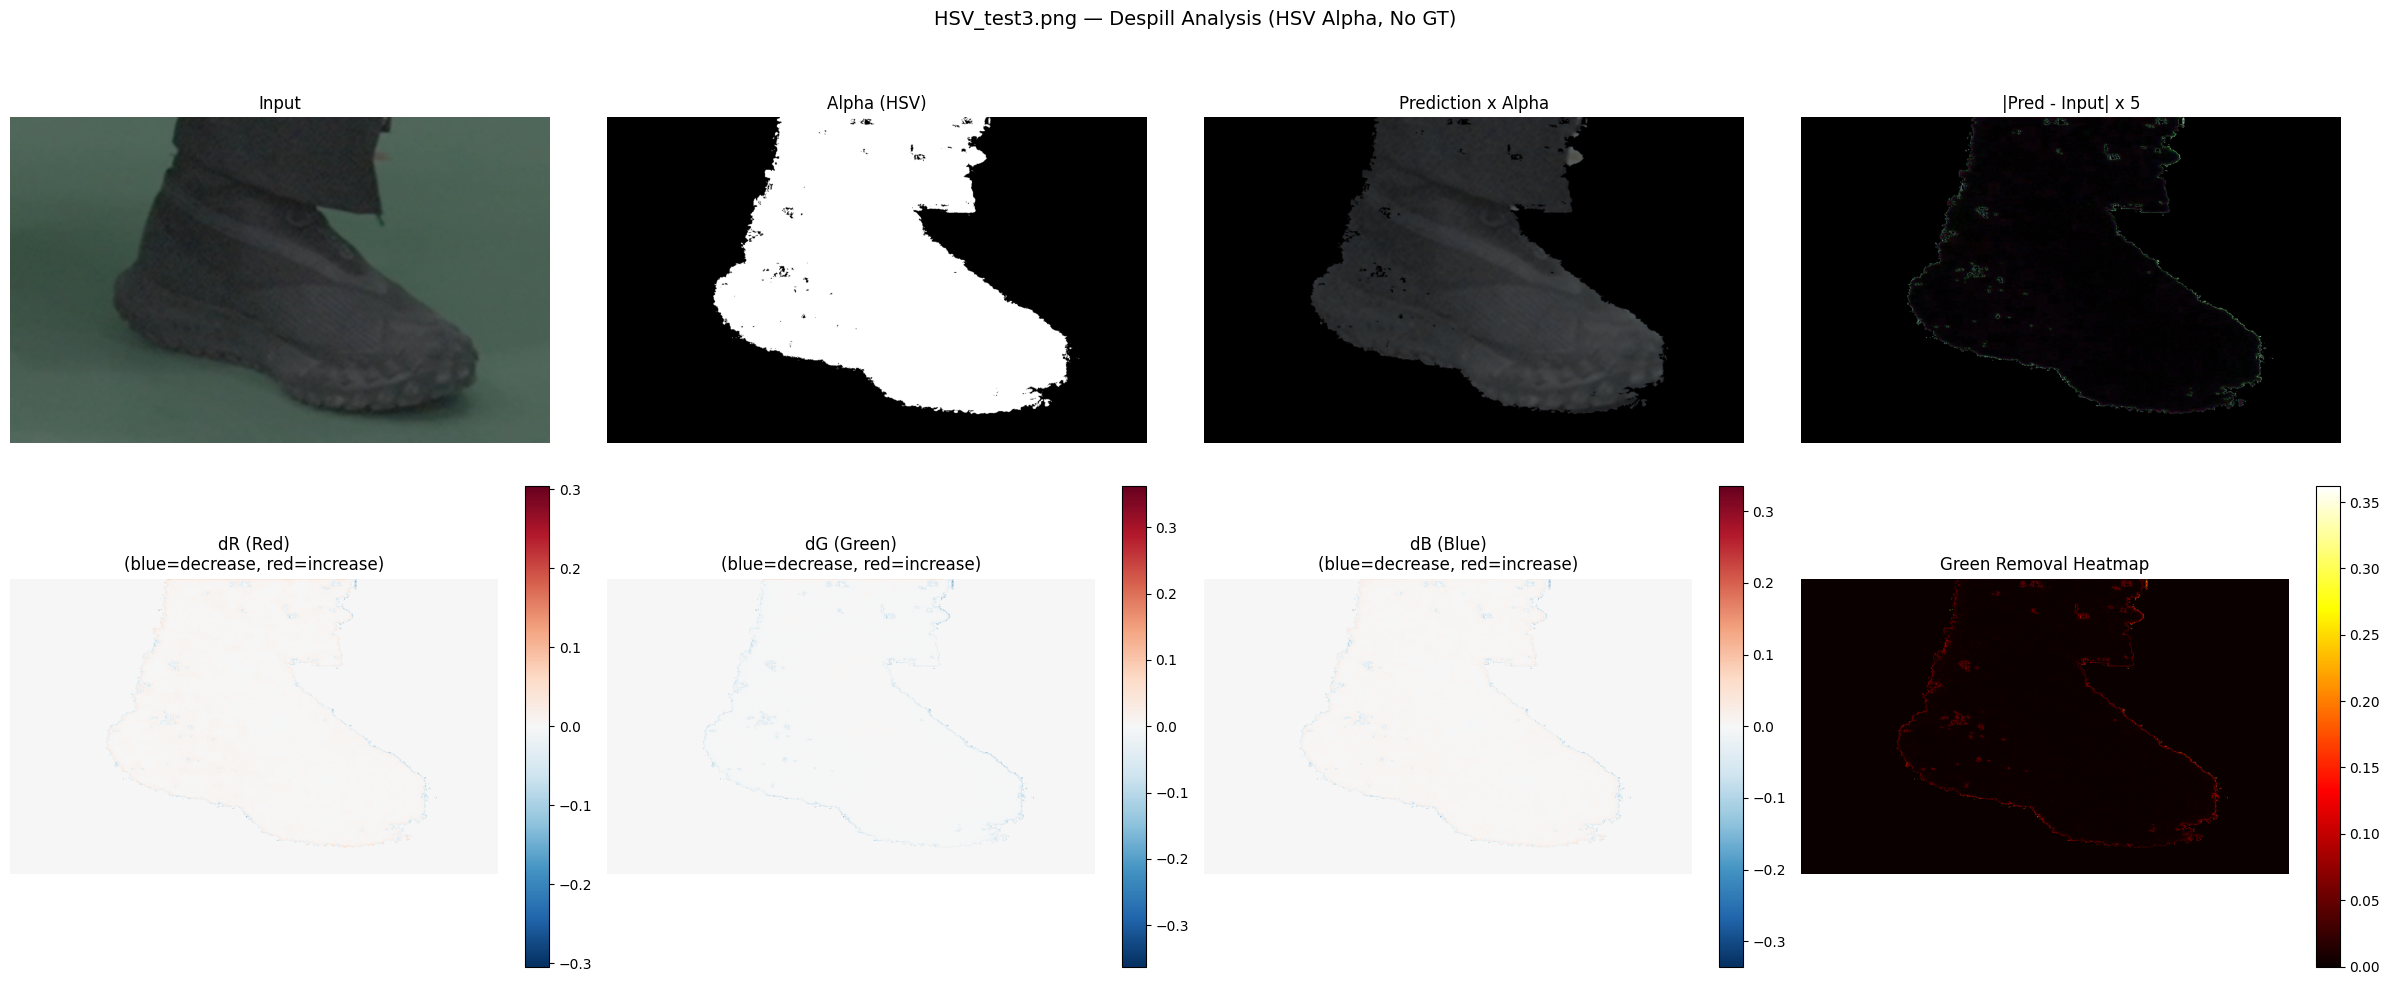

In [9]:
# Despill Analysis (HSV Alpha, No GT)
test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])

fname = test_files[5]

img_path = os.path.join(TEST_DIR, fname)
image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
h_orig, w_orig = image.shape[:2]
image_np = image.astype(np.float32) / 255.0

hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
green_mask = cv2.inRange(hsv, np.array([35, 40, 40]), np.array([85, 255, 255]))
alpha_np = 1.0 - green_mask.astype(np.float32) / 255.0

image_small = cv2.resize(image_np, (INFER_SIZE, INFER_SIZE))
alpha_small = cv2.resize(alpha_np, (INFER_SIZE, INFER_SIZE))

image_t = torch.from_numpy(image_small).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
alpha_t = torch.from_numpy(alpha_small).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

with torch.no_grad():
    pred = model(image_t, alpha_t)
pred_np = cv2.resize(pred.squeeze(0).permute(1, 2, 0).cpu().numpy(), (w_orig, h_orig))
torch.cuda.empty_cache()

alpha_3ch = alpha_np[:, :, np.newaxis]
input_masked = image_np * alpha_3ch
pred_masked  = pred_np * alpha_3ch

diff = (pred_np - image_np) * alpha_3ch
diff_abs = np.abs(diff)
diff_green = -diff[:, :, 1] * alpha_3ch[:, :, 0]

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle(f'{fname} — Despill Analysis (HSV Alpha, No GT)', fontsize=14)

axes[0, 0].imshow(np.clip(image_np, 0, 1))
axes[0, 0].set_title('Input')

axes[0, 1].imshow(np.clip(alpha_np, 0, 1), cmap='gray')
axes[0, 1].set_title('Alpha (HSV)')

axes[0, 2].imshow(np.clip(pred_masked, 0, 1))
axes[0, 2].set_title('Prediction x Alpha')

axes[0, 3].imshow(np.clip(diff_abs * 5.0, 0, 1))
axes[0, 3].set_title('|Pred - Input| x 5')

ch_names = ['dR (Red)', 'dG (Green)', 'dB (Blue)']
for c in range(3):
    ch_diff = diff[:, :, c]
    vmax = max(np.abs(ch_diff).max(), 1e-5)
    im = axes[1, c].imshow(ch_diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[1, c].set_title(f'{ch_names[c]}\n(blue=decrease, red=increase)')
    plt.colorbar(im, ax=axes[1, c], fraction=0.046)

im = axes[1, 3].imshow(diff_green, cmap='hot', vmin=0, vmax=diff_green.max() + 1e-5)
axes[1, 3].set_title('Green Removal Heatmap')
plt.colorbar(im, ax=axes[1, 3], fraction=0.046)

for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()


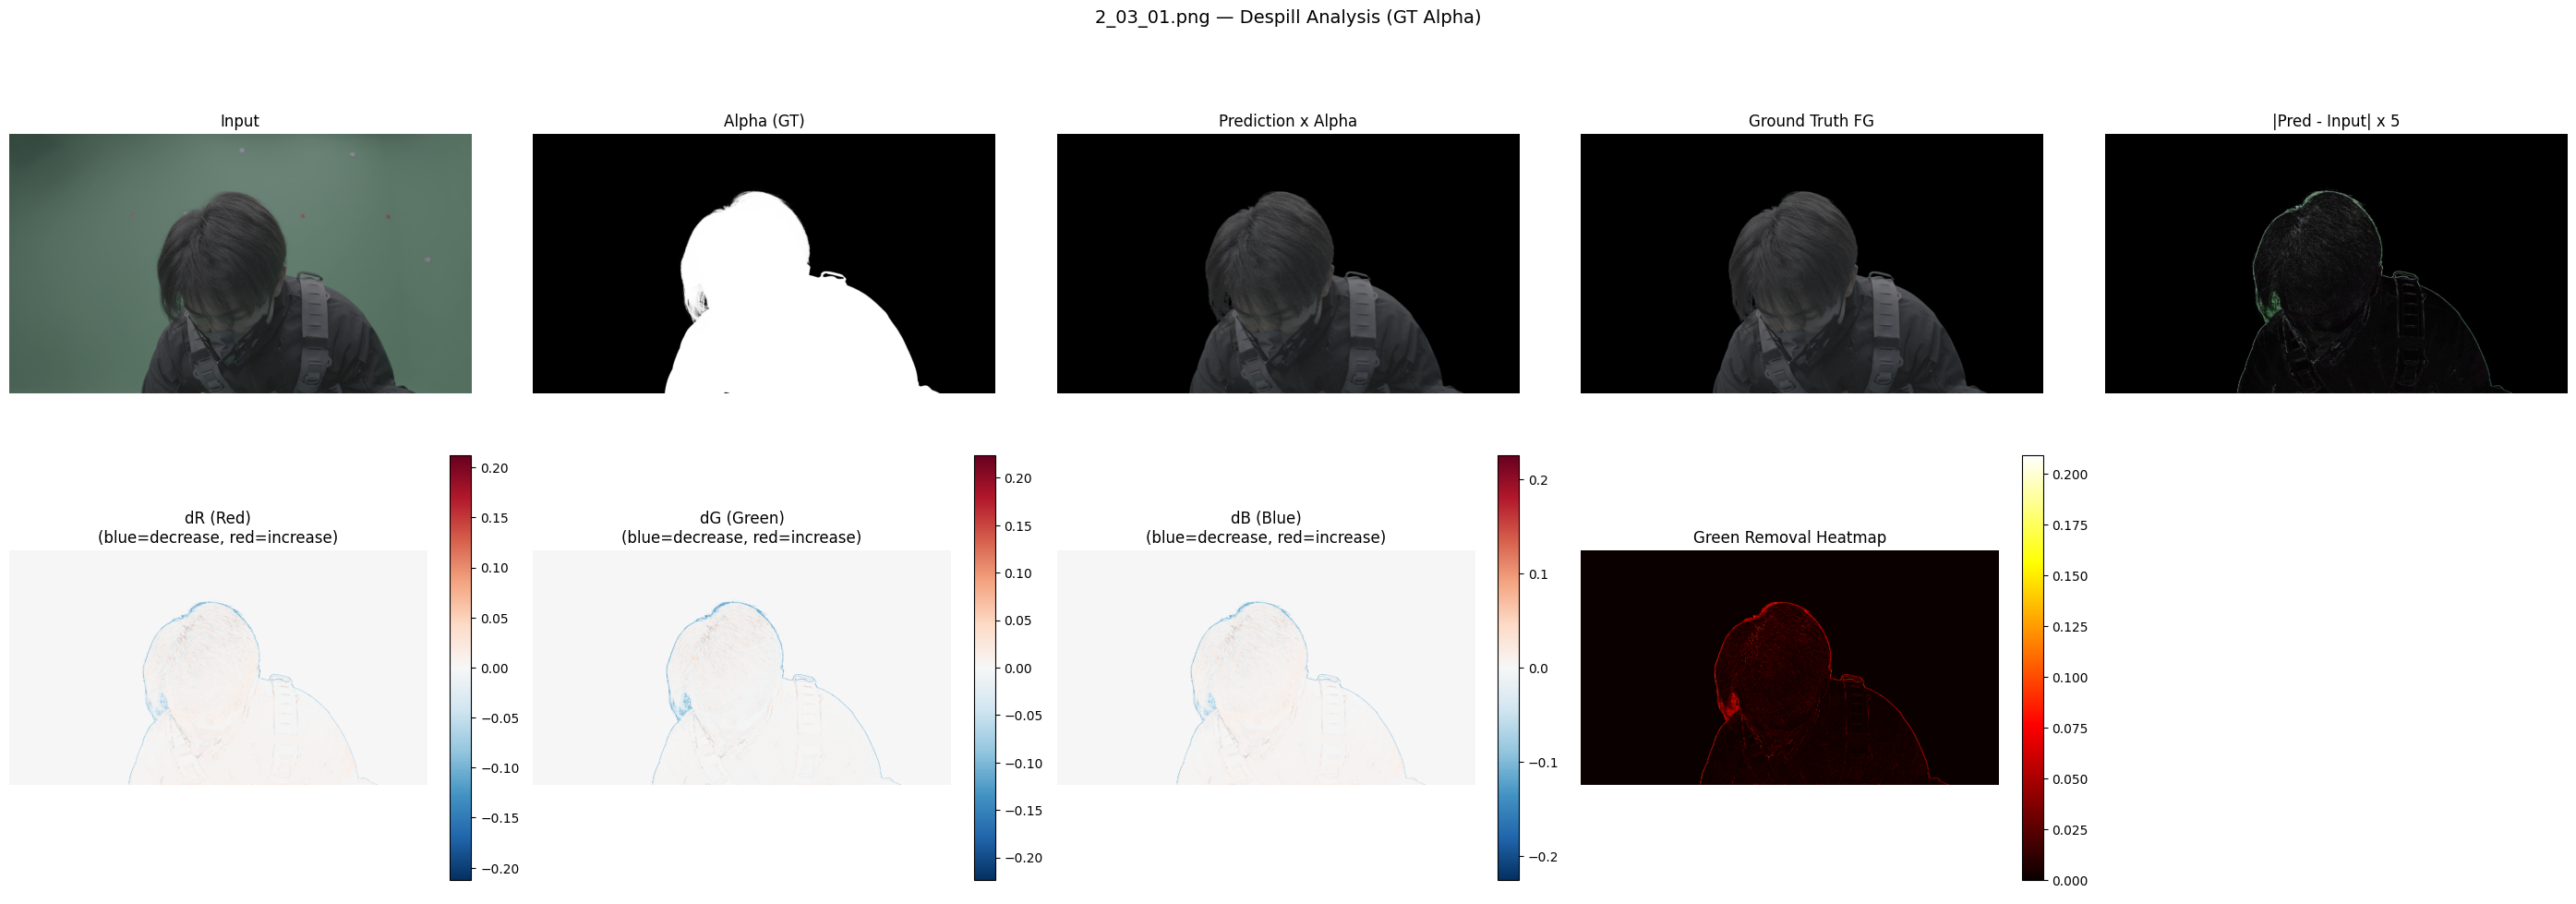

In [10]:
# Despill Analysis (GT Alpha)

test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])

fname = test_files[0]

fg_path = get_fg_path(fname)
fg_gt = cv2.imread(fg_path, cv2.IMREAD_UNCHANGED)

if fg_gt is None or fg_gt.ndim != 3 or fg_gt.shape[2] != 4:
    print(f"[ERROR] '{fname}' has no valid GT RGBA file at: {fg_path}")
    print(f"Available images with GT:")
    for i, f in enumerate(test_files):
        p = get_fg_path(f)
        g = cv2.imread(p, cv2.IMREAD_UNCHANGED)
        if g is not None and g.ndim == 3 and g.shape[2] == 4:
            print(f"   [{i}] {f}")
else:
    fg_gt = fg_gt.astype(np.float32) / 255.0
    fg_rgba = cv2.cvtColor(fg_gt, cv2.COLOR_BGRA2RGBA)
    gt_alpha = fg_rgba[:, :, 3]
    gt_fg    = fg_rgba[:, :, :3]

    img_path = os.path.join(TEST_DIR, fname)
    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h_orig, w_orig = image.shape[:2]
    image_np = image.astype(np.float32) / 255.0

    image_small = cv2.resize(image_np, (INFER_SIZE, INFER_SIZE))
    alpha_small = cv2.resize(gt_alpha, (INFER_SIZE, INFER_SIZE))

    image_t = torch.from_numpy(image_small).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
    alpha_t = torch.from_numpy(alpha_small).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        pred = model(image_t, alpha_t)
    pred_np = cv2.resize(pred.squeeze(0).permute(1, 2, 0).cpu().numpy(), (w_orig, h_orig))
    torch.cuda.empty_cache()

    alpha_3ch = gt_alpha[:, :, np.newaxis]
    input_masked = image_np * alpha_3ch
    pred_masked  = pred_np * alpha_3ch

    diff = (pred_np - image_np) * alpha_3ch
    diff_abs = np.abs(diff)
    diff_green = -diff[:, :, 1] * alpha_3ch[:, :, 0]

    fig, axes = plt.subplots(2, 5, figsize=(28, 10))
    fig.suptitle(f'{fname} — Despill Analysis (GT Alpha)', fontsize=14)

    axes[0, 0].imshow(np.clip(image_np, 0, 1))
    axes[0, 0].set_title('Input')

    axes[0, 1].imshow(np.clip(gt_alpha, 0, 1), cmap='gray')
    axes[0, 1].set_title('Alpha (GT)')

    axes[0, 2].imshow(np.clip(pred_masked, 0, 1))
    axes[0, 2].set_title('Prediction x Alpha')

    axes[0, 3].imshow(np.clip(gt_fg * alpha_3ch, 0, 1))
    axes[0, 3].set_title('Ground Truth FG')

    axes[0, 4].imshow(np.clip(diff_abs * 5.0, 0, 1))
    axes[0, 4].set_title('|Pred - Input| x 5')

    ch_names = ['dR (Red)', 'dG (Green)', 'dB (Blue)']
    for c in range(3):
        ch_diff = diff[:, :, c]
        vmax = max(np.abs(ch_diff).max(), 1e-5)
        im = axes[1, c].imshow(ch_diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        axes[1, c].set_title(f'{ch_names[c]}\n(blue=decrease, red=increase)')
        plt.colorbar(im, ax=axes[1, c], fraction=0.046)

    im = axes[1, 3].imshow(diff_green, cmap='hot', vmin=0, vmax=diff_green.max() + 1e-5)
    axes[1, 3].set_title('Green Removal Heatmap')
    plt.colorbar(im, ax=axes[1, 3], fraction=0.046)

    axes[1, 4].axis('off')

    for ax in axes.flat:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

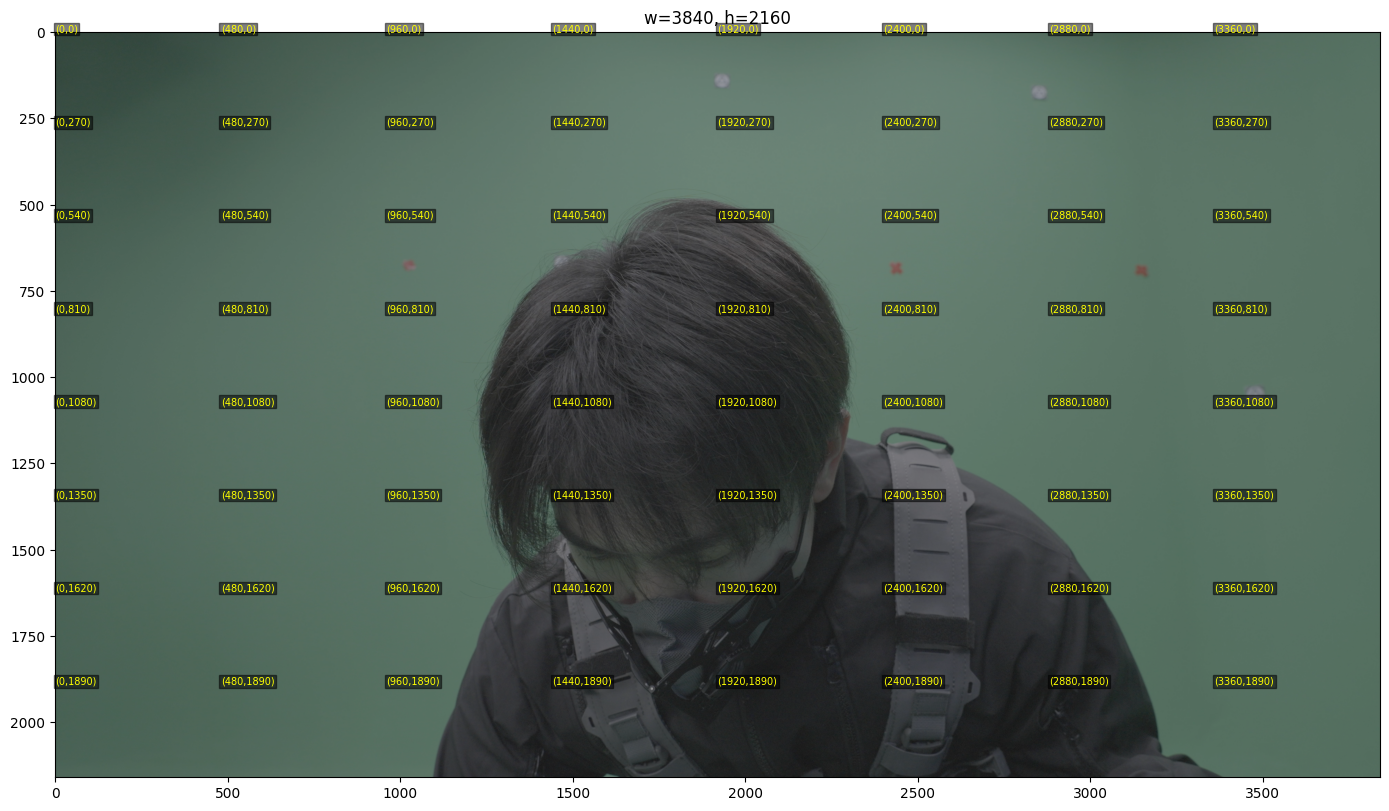

In [27]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(np.clip(image_np, 0, 1))

h, w = image_np.shape[:2]
for yi in range(0, h, h // 8):
    for xi in range(0, w, w // 8):
        ax.text(xi, yi, f'({xi},{yi})', color='yellow', fontsize=7,
                bbox=dict(fc='black', alpha=0.5, pad=1))

ax.set_title(f"w={w}, h={h}")
plt.tight_layout()
plt.show()

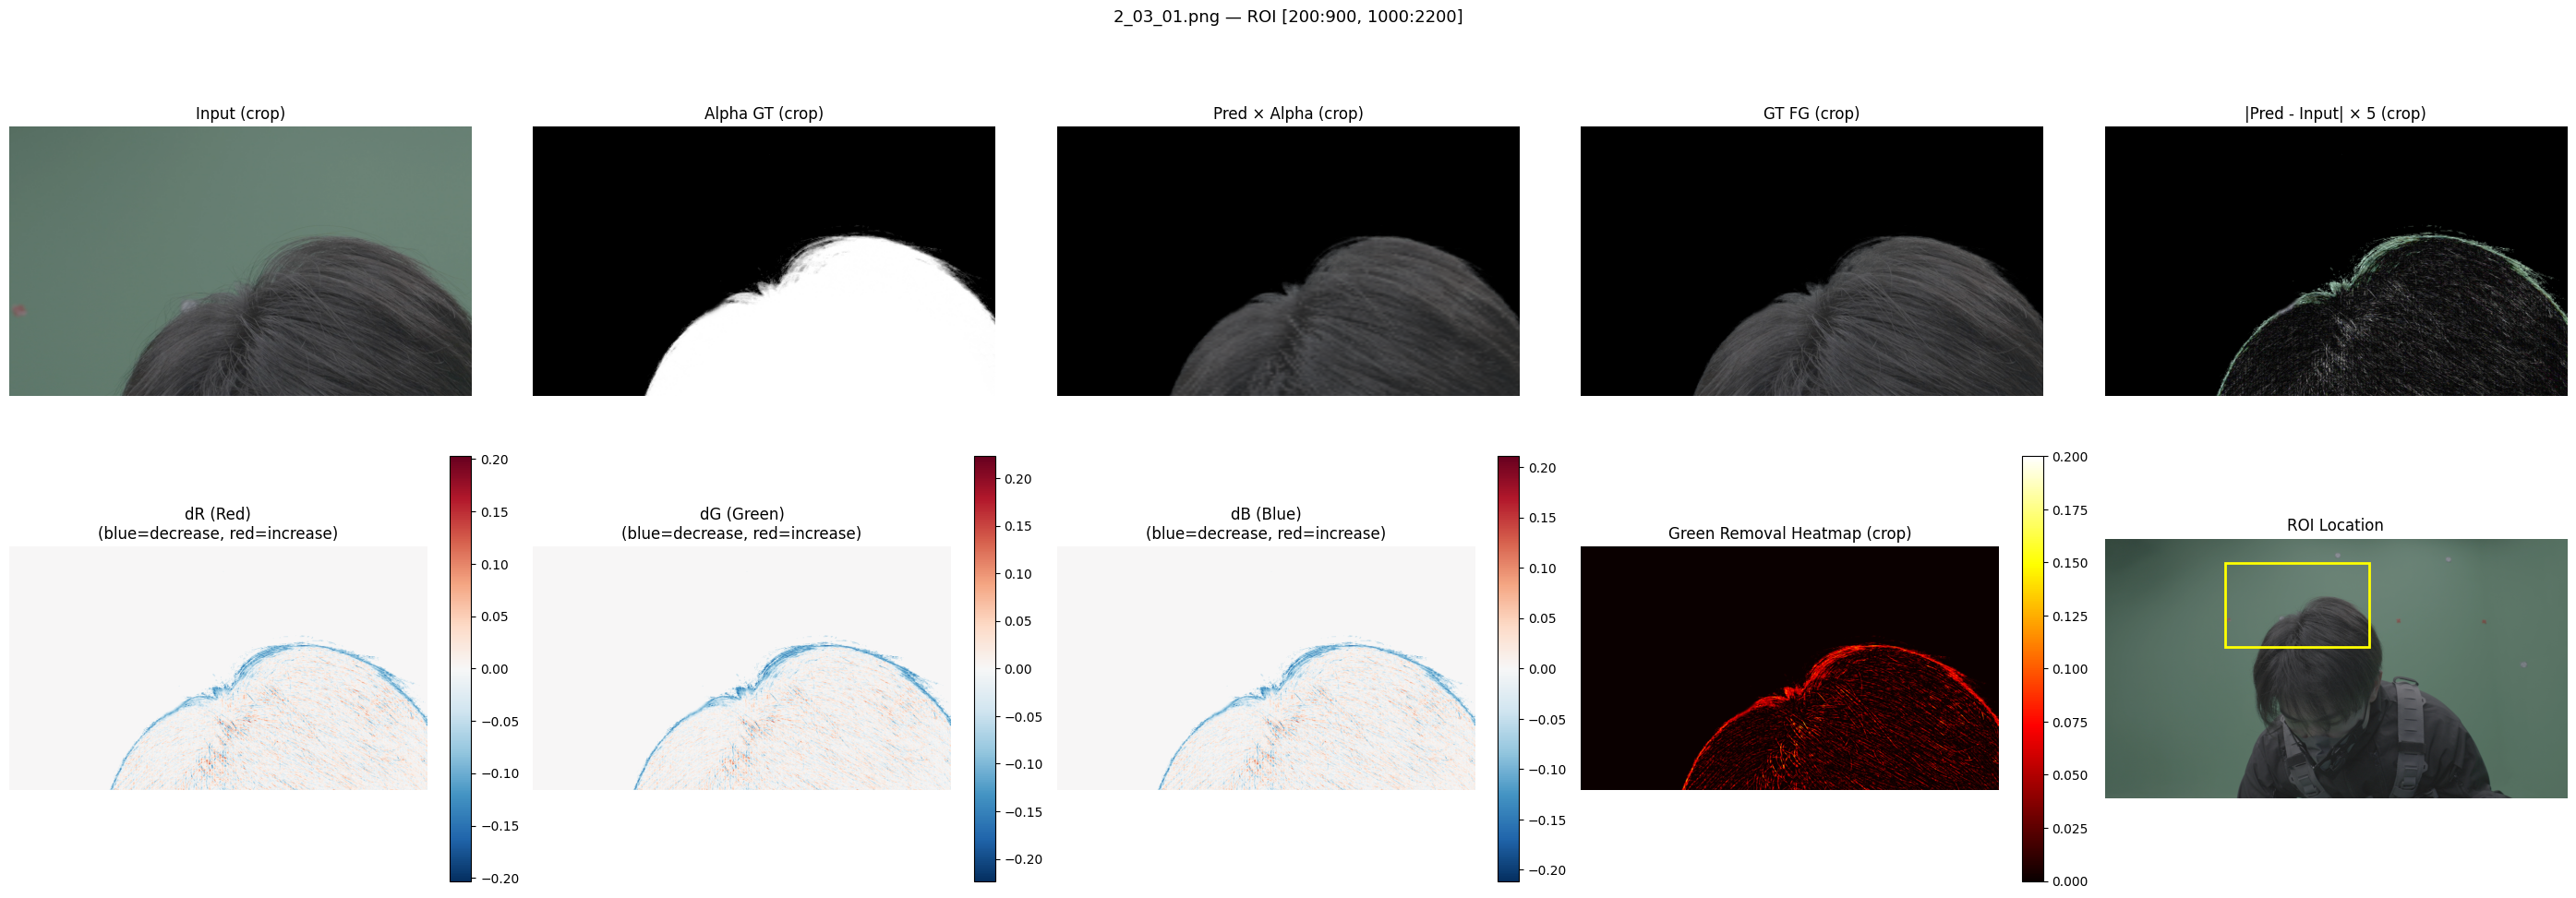

In [32]:
# Cell: Despill Local ROI Analysis
# Requires: image_np, pred_np, gt_alpha, gt_fg, fname

ROI = (200, 900, 1000, 2200)  # (y0, y1, x0, x1)

y0, y1, x0, x1 = ROI
alpha_3ch = gt_alpha[:, :, np.newaxis]

def crop(arr):
    return arr[y0:y1, x0:x1]

c_input     = crop(image_np)
c_alpha     = crop(gt_alpha)
c_pred      = crop(pred_np)
c_gt_fg     = crop(gt_fg)
c_alpha_3ch = crop(alpha_3ch)

c_pred_masked = c_pred  * c_alpha_3ch
c_gt_masked   = c_gt_fg * c_alpha_3ch
c_diff        = (c_pred - c_input) * c_alpha_3ch
c_diff_abs    = np.abs(c_diff)
c_diff_green  = -c_diff[:, :, 1] * c_alpha_3ch[:, :, 0]

import matplotlib.patches as patches

fig, axes = plt.subplots(2, 5, figsize=(28, 10))
fig.suptitle(f'{fname} — ROI [{y0}:{y1}, {x0}:{x1}]', fontsize=13)

axes[0, 0].imshow(np.clip(c_input, 0, 1));              axes[0, 0].set_title('Input (crop)')
axes[0, 1].imshow(np.clip(c_alpha, 0, 1), cmap='gray'); axes[0, 1].set_title('Alpha GT (crop)')
axes[0, 2].imshow(np.clip(c_pred_masked, 0, 1));        axes[0, 2].set_title('Pred × Alpha (crop)')
axes[0, 3].imshow(np.clip(c_gt_masked, 0, 1));          axes[0, 3].set_title('GT FG (crop)')
axes[0, 4].imshow(np.clip(c_diff_abs * 5.0, 0, 1));     axes[0, 4].set_title('|Pred - Input| × 5 (crop)')

for c, name in enumerate(['dR (Red)', 'dG (Green)', 'dB (Blue)']):
    ch   = c_diff[:, :, c]
    vmax = max(np.abs(ch).max(), 1e-5)
    im   = axes[1, c].imshow(ch, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[1, c].set_title(f'{name}\n(blue=decrease, red=increase)')
    plt.colorbar(im, ax=axes[1, c], fraction=0.046)

im = axes[1, 3].imshow(c_diff_green, cmap='hot', vmin=0, vmax=c_diff_green.max() + 1e-5)
axes[1, 3].set_title('Green Removal Heatmap (crop)')
plt.colorbar(im, ax=axes[1, 3], fraction=0.046)

axes[1, 4].imshow(np.clip(image_np, 0, 1))
axes[1, 4].add_patch(patches.Rectangle(
    (x0, y0), x1 - x0, y1 - y0,
    linewidth=2, edgecolor='yellow', facecolor='none'
))
axes[1, 4].set_title('ROI Location')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

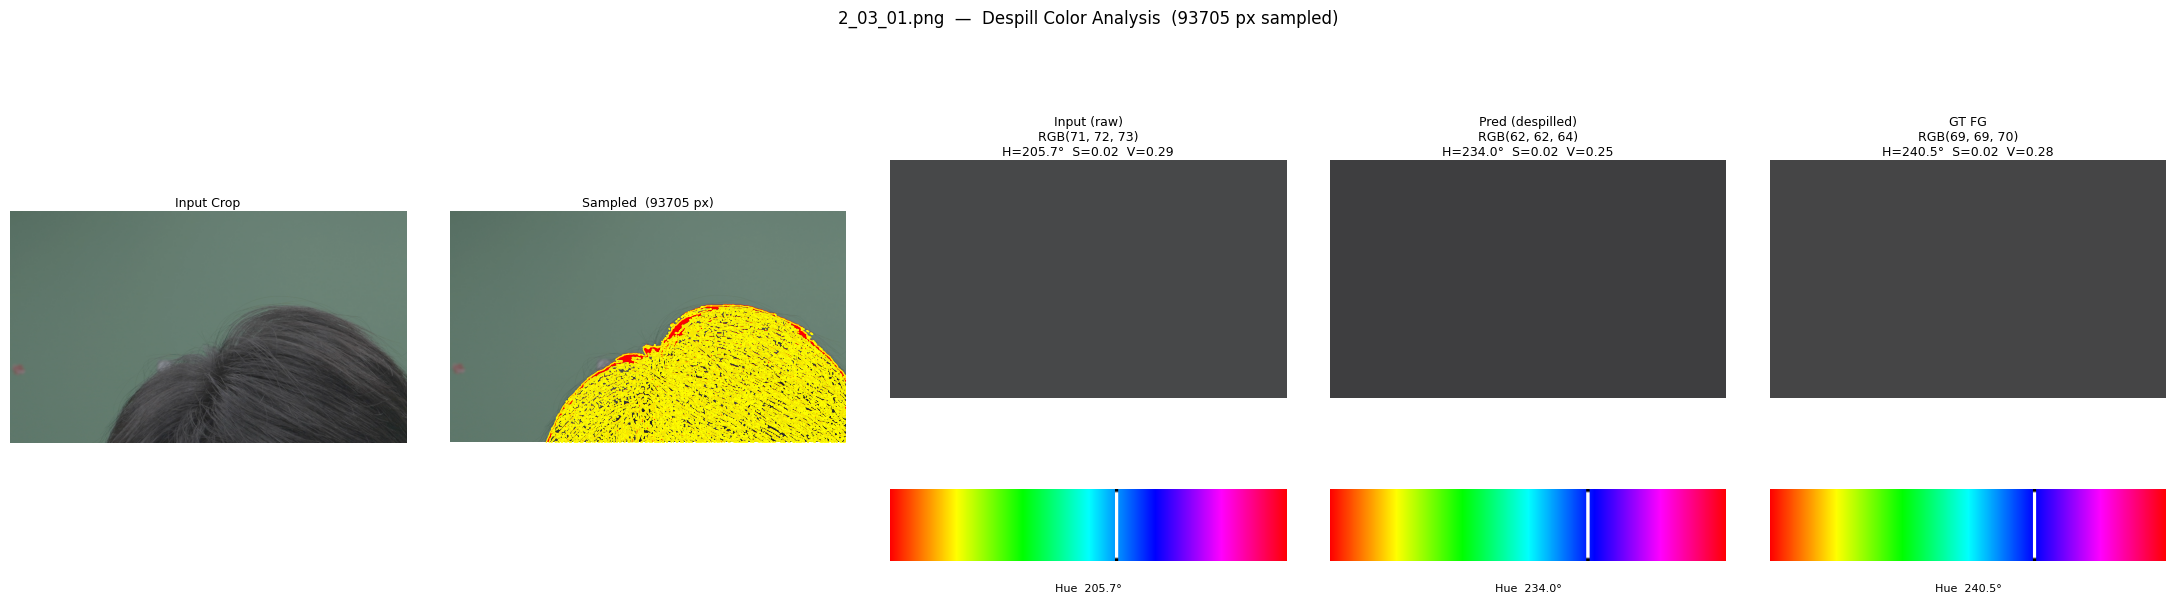

In [33]:
import colorsys
from skimage import measure

def make_hue_bar(pixels, width=360, height=24):
    color = np.clip(pixels.mean(axis=0), 0, 1)
    h, s, v = colorsys.rgb_to_hsv(*color)
    bar = np.zeros((height, width, 3))
    for x in range(width):
        bar[:, x] = colorsys.hsv_to_rgb(x / width, 1.0, 1.0)
    mx = int(h * width)
    bar[:, max(0, mx - 1):mx + 2] = 1.0
    bar[0,  max(0, mx - 1):mx + 2] = 0.0
    bar[-1, max(0, mx - 1):mx + 2] = 0.0
    return bar, h * 360

mask_overlay = np.clip(c_input.copy(), 0, 1)
mask_overlay[spill_mask, 0] = 1.0
mask_overlay[spill_mask, 1] = 0.0
mask_overlay[spill_mask, 2] = 0.0

entries = [
    (input_pixels, 'Input (raw)'),
    (pred_pixels,  'Pred (despilled)'),
    (gt_pixels,    'GT FG'),
]

fig = plt.figure(figsize=(22, 6))
fig.suptitle(
    f'{fname}  —  Despill Color Analysis  ({spill_mask.sum()} px sampled)',
    fontsize=12
)

# Each column occupies 1/5 of figure width
col_w = 1 / 5
pad   = 0.02

def add_col(fig, col_idx, image, title, hue_bar=None, hue_deg=None, subtitle=None):
    x0 = col_idx * col_w + pad / 2
    w  = col_w - pad

    if hue_bar is not None:
        # swatch: top 78%, bar: bottom 14%, gap 8%
        ax_img = fig.add_axes([x0, 0.22, w, 0.62])
        ax_bar = fig.add_axes([x0, 0.06, w, 0.12])
        ax_bar.imshow(hue_bar, aspect='auto')
        ax_bar.set_xticks([]); ax_bar.set_yticks([])
        for spine in ax_bar.spines.values():
            spine.set_visible(False)
        fig.text(x0 + w / 2, 0.01, f'Hue  {hue_deg:.1f}°',
                 ha='center', fontsize=8)
    else:
        ax_img = fig.add_axes([x0, 0.06, w, 0.78])

    ax_img.imshow(image)
    ax_img.axis('off')
    ax_img.set_title(title, fontsize=9, pad=4)
    if subtitle:
        ax_img.set_xlabel(subtitle, fontsize=8, labelpad=4)

# Col 0 & 1: location maps
add_col(fig, 0, np.clip(c_input, 0, 1), 'Input Crop')
masked_img = mask_overlay.copy()
contour_ax_placeholder = np.clip(c_input, 0, 1)  # draw contours after

x0 = 1 * col_w + pad / 2
w  = col_w - pad
ax_mask = fig.add_axes([x0, 0.06, w, 0.78])
ax_mask.imshow(mask_overlay)
for contour in measure.find_contours(spill_mask.astype(float), 0.5):
    ax_mask.plot(contour[:, 1], contour[:, 0], lw=0.9, color='yellow', alpha=0.9)
ax_mask.set_title(f'Sampled  ({spill_mask.sum()} px)', fontsize=9, pad=4)
ax_mask.axis('off')

# Cols 2-4: swatch + hue bar
for i, (pixels, label) in enumerate(entries):
    mean     = np.clip(pixels.mean(axis=0), 0, 1)
    h, s, v  = colorsys.rgb_to_hsv(*mean)
    bar, hue = make_hue_bar(pixels)
    swatch   = np.ones((120, 200, 3)) * mean

    add_col(
        fig, i + 2, swatch,
        title=f'{label}\nRGB({int(mean[0]*255)}, {int(mean[1]*255)}, {int(mean[2]*255)})\nH={hue:.1f}°  S={s:.2f}  V={v:.2f}',
        hue_bar=bar, hue_deg=hue
    )

plt.show()